# House Price Prediction
## A Complete Data Science Project

## Project Overview

This project builds a machine learning model to predict house prices
based on 79 features such as location, size, quality, and condition.
The dataset is sourced from the Kaggle House Prices competition.

The project covers the following steps:
1. Data Collection and Exploration
2. Data Cleaning and Transformation
3. Exploratory Data Analysis
4. Feature Selection
5. Model Development
6. Model Evaluation and Hyperparameter Tuning
7. Model Deployment using Streamlit

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np

print("Importing libraries completed")

Importing libraries completed


## 1. Data Collection and Exploration
### 1.1 Loading the Dataset

In [2]:
df = pd.read_csv('train.csv')

print("Dataset loaded successfully")

Dataset loaded successfully


In [3]:
print("Shape:", df.shape)

Shape: (1460, 81)


In [4]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [8]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage': missing_percent})
print(missing_df)

              Missing Count  Missing Percentage
PoolQC                 1453           99.520548
MiscFeature            1406           96.301370
Alley                  1369           93.767123
Fence                  1179           80.753425
MasVnrType              872           59.726027
FireplaceQu             690           47.260274
LotFrontage             259           17.739726
GarageType               81            5.547945
GarageYrBlt              81            5.547945
GarageFinish             81            5.547945
GarageQual               81            5.547945
GarageCond               81            5.547945
BsmtFinType2             38            2.602740
BsmtExposure             38            2.602740
BsmtFinType1             37            2.534247
BsmtCond                 37            2.534247
BsmtQual                 37            2.534247
MasVnrArea                8            0.547945
Electrical                1            0.068493


### 1.2 Checking Data Types

In [9]:
print("Numerical columns:", df.select_dtypes(include=['int64', 'float64']).shape[1])
print("Categorical columns:", df.select_dtypes(include=['object']).shape[1])

Numerical columns: 38
Categorical columns: 43


In [10]:
print(df['SalePrice'].skew())

1.8828757597682129


## 2. Data Cleaning and Transformation
### 2.1 Dropping High Missing Value Columns

In [11]:
cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'Id']
df = df.drop(columns=cols_to_drop)
print("Columns after dropping:", df.shape[1])

Columns after dropping: 76


### 2.2 Filling Missing Values

In [12]:
# These columns are missing because the house simply has no fireplace, garage or basement
# Missing here means 'None', not unknown

none_cols = ['FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 
             'GarageCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 
             'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']

for col in none_cols:
    df[col] = df[col].fillna('None')

print("Done filling categorical missing values with None")

Done filling categorical missing values with None


In [13]:
# GarageYrBlt is missing because the house has no garage
# We fill it with 0 to represent no garage year

df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

print("Done filling numerical missing values with 0")

Done filling numerical missing values with 0


In [14]:
# LotFrontage is genuinely unknown, so we fill it with the median value
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

# Electrical has only 1 missing value, we fill it with the most common value
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

print("Done filling LotFrontage and Electrical")

Done filling LotFrontage and Electrical


In [15]:
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
print("Remaining missing values:")
print(remaining_missing)

Remaining missing values:
Series([], dtype: int64)


In [16]:
print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (1460, 76)


### 2.3 Outlier Detection and Treatment

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

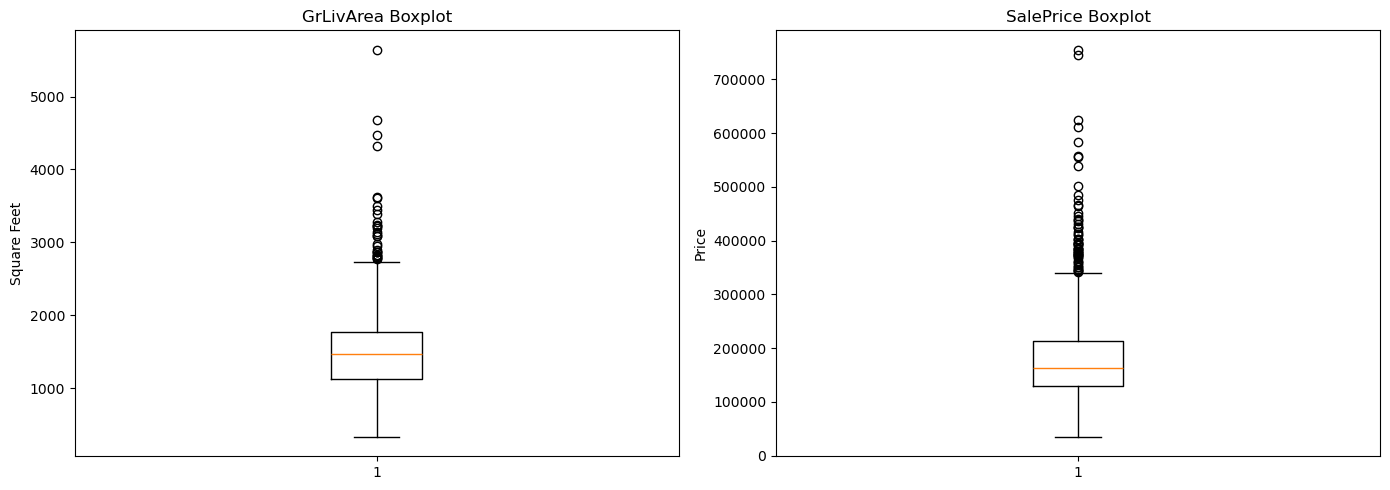

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df['GrLivArea'])
axes[0].set_title('GrLivArea Boxplot')
axes[0].set_ylabel('Square Feet')

axes[1].boxplot(df['SalePrice'])
axes[1].set_title('SalePrice Boxplot')
axes[1].set_ylabel('Price')

plt.tight_layout()
plt.show()

In [19]:
# Removing extreme outliers in GrLivArea
# Houses with living area above 4000 sq ft are extreme outliers
df = df[df['GrLivArea'] < 4000]

print("Dataset shape after removing outliers:", df.shape)

Dataset shape after removing outliers: (1456, 76)


### 2.4 Encoding Categorical Variables

In [20]:
# Ordinal columns have a natural order or ranking
# We map them manually to preserve that order

ordinal_mappings = {
    'ExterQual': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1},
    'ExterCond': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1},
    'BsmtQual': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0},
    'BsmtCond': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0},
    'HeatingQC': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1},
    'KitchenQual': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1},
    'FireplaceQu': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0},
    'GarageQual': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0},
    'GarageCond': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0},
    'BsmtExposure': {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0},
    'BsmtFinType1': {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0},
    'BsmtFinType2': {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0},
    'GarageFinish': {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0},
    'PavedDrive': {'Y': 2, 'P': 1, 'N': 0},
    'CentralAir': {'Y': 1, 'N': 0}
}

for col, mapping in ordinal_mappings.items():
    df[col] = df[col].map(mapping)

print("Ordinal encoding done")

Ordinal encoding done


In [21]:
# Nominal columns have no natural order
# We use One Hot Encoding for these

nominal_cols = ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
                'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
                'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
                'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'Electrical',
                'Functional', 'GarageType', 'SaleType', 'SaleCondition']

df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print("One Hot Encoding done")
print("Dataset shape after encoding:", df.shape)

One Hot Encoding done
Dataset shape after encoding: (1456, 202)


### 2.5 Feature Transformation

In [22]:
import numpy as np

df['SalePrice'] = np.log1p(df['SalePrice'])

print("SalePrice skewness after log transformation:", df['SalePrice'].skew())

SalePrice skewness after log transformation: 0.06546006911025826


In [23]:
print("Final dataset shape:", df.shape)
print("Missing values remaining:", df.isnull().sum().sum())
print("Data types:")
print(df.dtypes.value_counts())

Final dataset shape: (1456, 202)
Missing values remaining: 0
Data types:
bool       150
int64       48
float64      4
Name: count, dtype: int64


## 3. Exploratory Data Analysis

### 3.1 Distribution of SalePrice

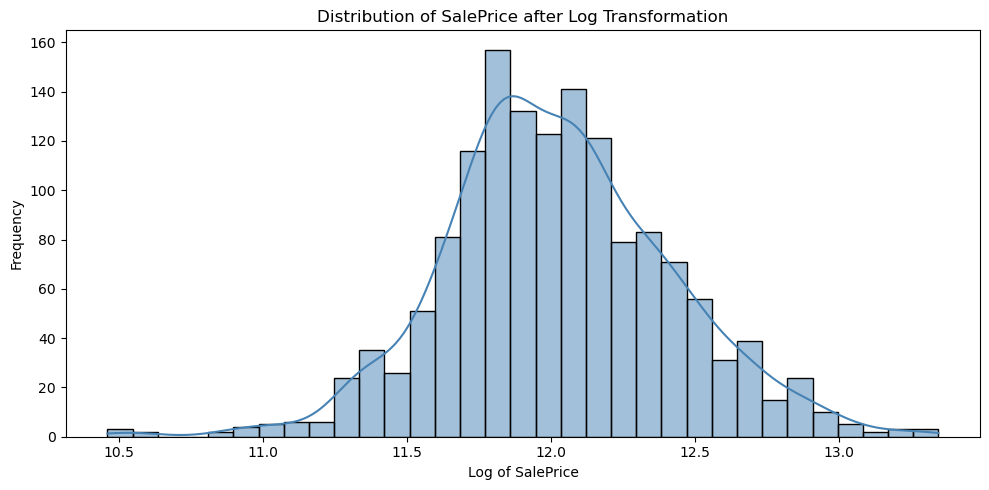

In [24]:
plt.figure(figsize=(10, 5))
sns.histplot(df['SalePrice'], kde=True, color='steelblue')
plt.title('Distribution of SalePrice after Log Transformation')
plt.xlabel('Log of SalePrice')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

The distribution of SalePrice after log transformation is approximately 
bell shaped and centered around 12.0 on the log scale, which corresponds 
to roughly $163,000 in actual price. The log transformation successfully 
reduced the skewness from 1.88 to 0.065, making the target variable 
suitable for linear modeling.

### 3.2 Correlation Heatmap

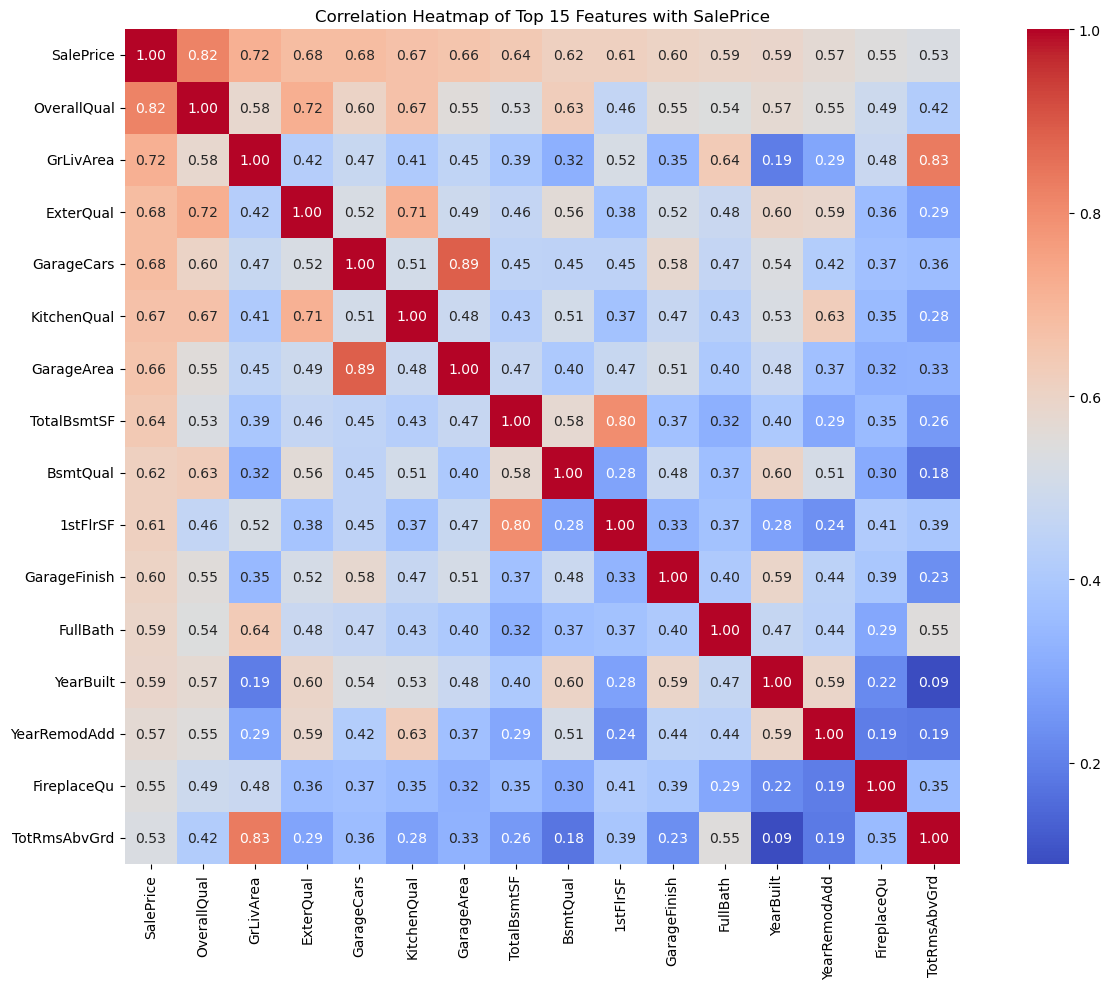

In [25]:
# Select only numerical columns for correlation
numerical_df = df.select_dtypes(include=['int64', 'float64', 'bool'])

# Get top 15 features most correlated with SalePrice
correlation = numerical_df.corr()
top_features = correlation['SalePrice'].abs().sort_values(ascending=False).head(16).index

plt.figure(figsize=(14, 10))
sns.heatmap(numerical_df[top_features].corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            square=True)
plt.title('Correlation Heatmap of Top 15 Features with SalePrice')
plt.tight_layout()
plt.show()

The heatmap reveals that OverallQual has the strongest correlation with 
SalePrice at 0.82, followed by GrLivArea at 0.72 and ExterQual at 0.68. 
We also notice that GarageCars and GarageArea are highly correlated with 
each other at 0.89, indicating multicollinearity which we will address 
in the feature selection step.

### 3.3 Overall Quality vs Sale Price

C:\Users\Sweta Khadka\AppData\Local\Temp\ipykernel_11216\3119259948.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='OverallQual', y='SalePrice', data=df, palette='RdYlGn')


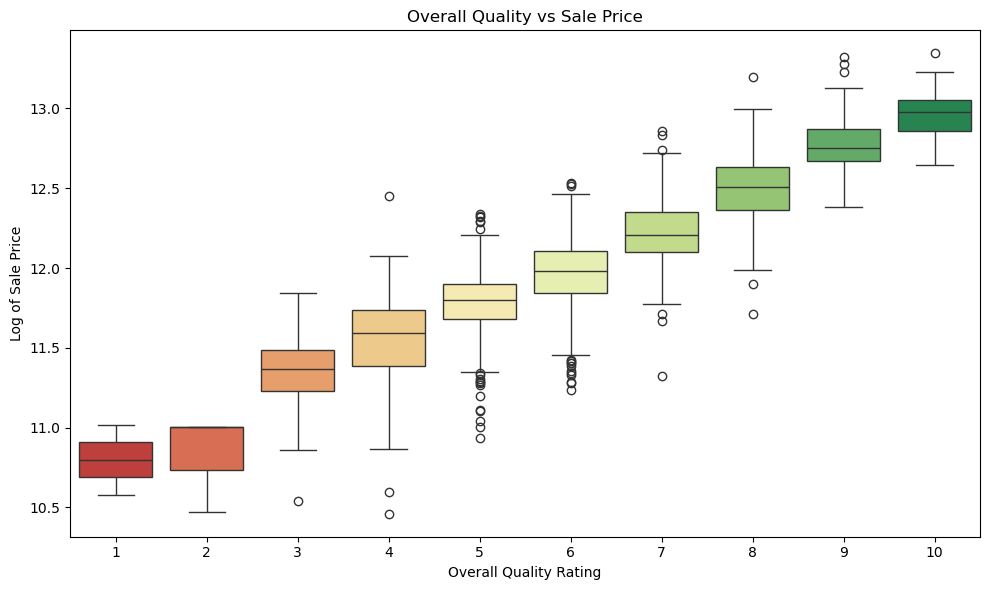

In [26]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='OverallQual', y='SalePrice', data=df, palette='RdYlGn')
plt.title('Overall Quality vs Sale Price')
plt.xlabel('Overall Quality Rating')
plt.ylabel('Log of Sale Price')
plt.tight_layout()
plt.show()

There is a clear and consistent positive relationship between Overall 
Quality and Sale Price. Houses rated 10 sell for nearly 9 times more 
than houses rated 1. This confirms that OverallQual is the single most 
powerful predictor in our dataset.

### 3.4 Living Area vs Sale Price

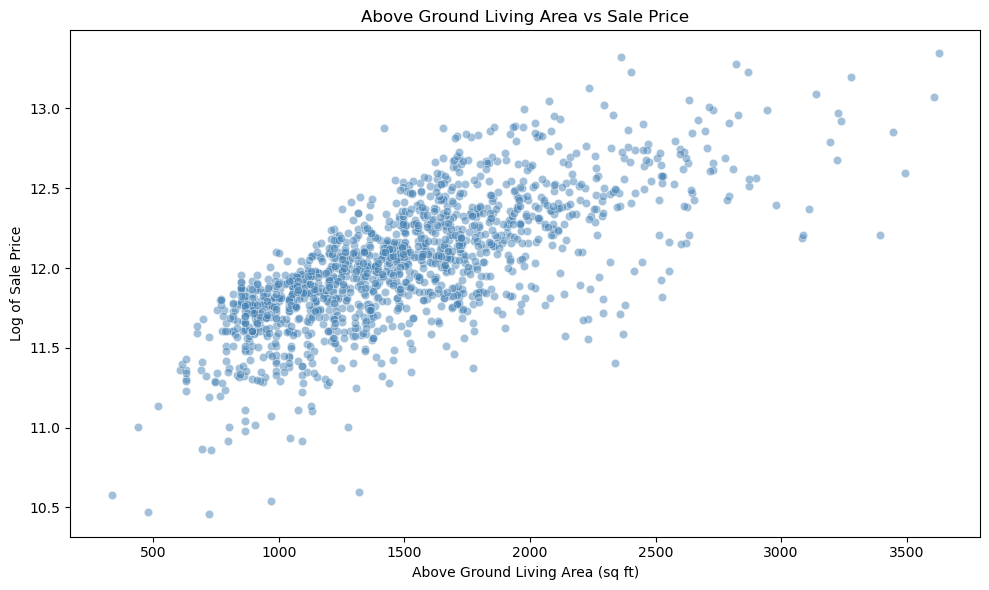

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df, alpha=0.5, color='steelblue')
plt.title('Above Ground Living Area vs Sale Price')
plt.xlabel('Above Ground Living Area (sq ft)')
plt.ylabel('Log of Sale Price')
plt.tight_layout()
plt.show()

The scatter plot shows a clear positive linear relationship between the 
above ground living area and sale price. As the living area increases, 
the sale price consistently increases as well. This confirms that 
GrLivArea is one of the strongest predictors of house price with a 
correlation of 0.72. The data points are reasonably well spread around 
an imaginary diagonal line from bottom left to top right, indicating 
a healthy linear relationship suitable for regression modeling.

### 3.5 Top 10 Features Correlated with Sale Price

C:\Users\Sweta Khadka\AppData\Local\Temp\ipykernel_11216\1144290675.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette='coolwarm')


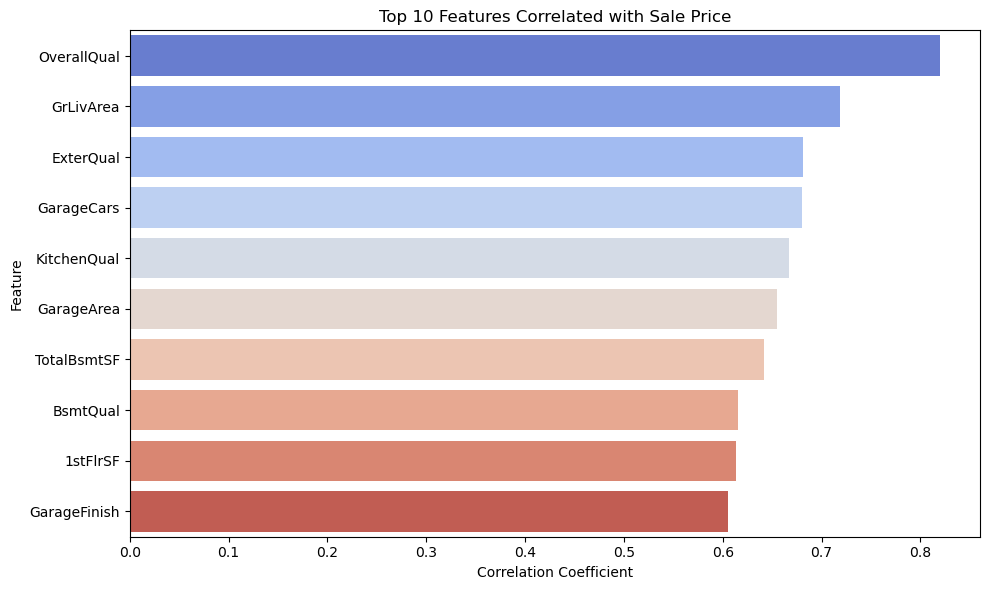

In [28]:
correlation = df.corr()['SalePrice'].abs().sort_values(ascending=False)
top_10 = correlation[1:11]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10.values, y=top_10.index, palette='coolwarm')
plt.title('Top 10 Features Correlated with Sale Price')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

The bar chart confirms that OverallQual is the strongest predictor of 
house price with a correlation of 0.82, followed by GrLivArea at 0.72. 
All top 10 features show a correlation above 0.60 with SalePrice, 
indicating that these features will be the most valuable inputs for 
our machine learning model.

## 4. Feature Selection

### 4.1 Removing Low Correlation Features

In [29]:
correlation = df.corr()['SalePrice'].abs()
relevant_features = correlation[correlation > 0.1].index.tolist()
print("Features kept:", len(relevant_features))
print("Features removed:", df.shape[1] - len(relevant_features))

Features kept: 95
Features removed: 107


In [30]:
df = df[relevant_features]
print("Dataset shape after feature selection:", df.shape)

Dataset shape after feature selection: (1456, 95)


### 4.2 Removing Multicollinearity

In [31]:
import numpy as np

corr_matrix = df.drop(columns=['SalePrice']).corr().abs()
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
cols_to_drop = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.85)]
print("Highly correlated features to drop:", cols_to_drop)

Highly correlated features to drop: ['FireplaceQu', 'GarageArea', 'GarageQual', 'GarageCond', 'Neighborhood_Somerst', 'RoofStyle_Hip', 'Exterior2nd_MetalSd', 'Exterior2nd_VinylSd', 'Exterior2nd_Wd Sdng', 'GarageType_None', 'SaleCondition_Partial']


In [32]:
df = df.drop(columns=cols_to_drop)
print("Dataset shape after removing multicollinearity:", df.shape)

Dataset shape after removing multicollinearity: (1456, 84)


We started with 202 features after encoding. After removing features 
with correlation below 0.1 with SalePrice, we reduced to 95 features. 
After removing multicollinear features with correlation above 0.85 
with each other, we arrived at a final set of 84 features. This clean 
and relevant feature set will help our model learn more effectively 
and generalize better to unseen data.

## 5. Model Development

### 5.1 Splitting Features and Target

In [33]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1456, 83)
Target shape: (1456,)


### 5.2 Splitting Data into Training and Testing Sets

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (1164, 83)
Testing set size: (292, 83)


### 5.3 Feature Scaling


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling done")


Scaling done


### 5.4 Training Models

We will train three different models and compare their performance. 
The three models are Linear Regression, Random Forest, and Gradient 
Boosting. Training multiple models and comparing them is a professional 
practice that ensures we select the best performing model for deployment.

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained successfully")

Linear Regression trained successfully
Random Forest trained successfully
Gradient Boosting trained successfully


## 6. Model Evaluation
### 6.1 Comparing Model Performance

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4), 'R2 Score': round(r2, 4)})

results_df = pd.DataFrame(results)
print(results_df)

               Model     MAE    RMSE  R2 Score
0  Linear Regression  0.0917  0.1274    0.8972
1      Random Forest  0.1051  0.1537    0.8505
2  Gradient Boosting  0.0951  0.1359    0.8831


Linear Regression achieved the highest R2 score of 0.8972, outperforming 
both Random Forest and Gradient Boosting. This indicates that the 
relationships between our selected features and SalePrice are largely 
linear in nature. We will proceed with Linear Regression as our primary 
model and perform hyperparameter tuning on Gradient Boosting as our 
secondary model for comparison.

### 6.2 Visualizing Model Performance

C:\Users\Sweta Khadka\AppData\Local\Temp\ipykernel_11216\2635710666.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=results_df, palette='coolwarm')


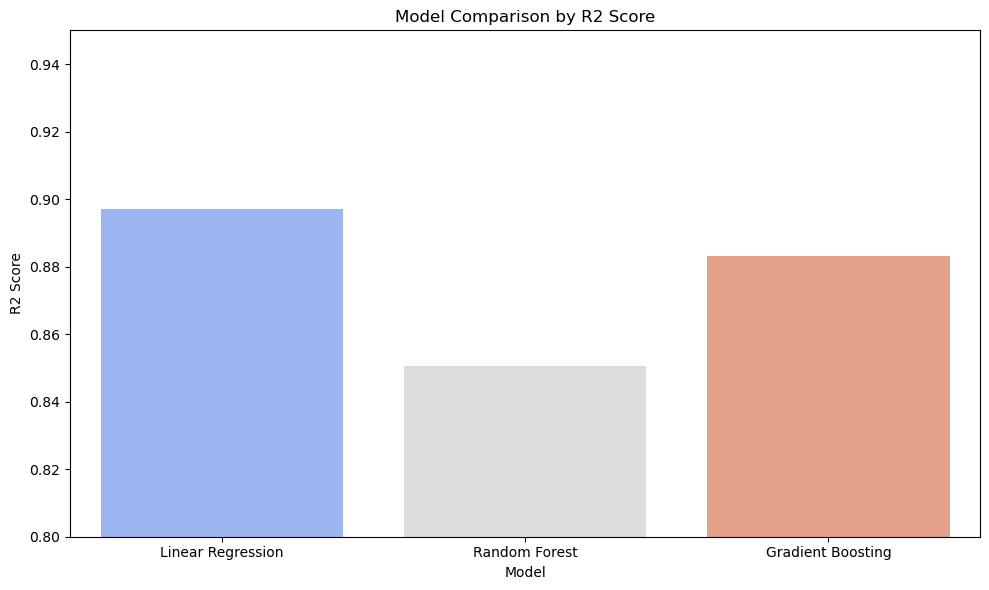

In [38]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2 Score', data=results_df, palette='coolwarm')
plt.title('Model Comparison by R2 Score')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.ylim(0.8, 0.95)
plt.tight_layout()
plt.show()

The bar chart clearly shows Linear Regression outperforming both 
Random Forest and Gradient Boosting in terms of R2 Score. This 
visual comparison makes it easy to communicate model performance 
to both technical and non technical audiences.

### 6.3 Hyperparameter Tuning

In [39]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4]
}

gb_model = GradientBoostingRegressor(random_state=42)
grid_search = GridSearchCV(gb_model, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best R2 Score from cross validation:", round(grid_search.best_score_, 4))

Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Best R2 Score from cross validation: 0.89




Hyperparameter tuning is the process of finding the optimal settings 
for a machine learning model before training. We use GridSearchCV which 
systematically tries every combination of parameters we specify and uses 
5 fold cross validation to evaluate each combination. This ensures we 
find the best possible configuration for our Gradient Boosting model 
without overfitting to the training data.

The parameters we tuned are:
- n_estimators: number of trees to build
- learning_rate: how fast the model learns
- max_depth: how deep each tree can grow

The best parameters found are learning_rate of 0.05, max_depth of 3, 
and n_estimators of 200. These settings produce a cross validation 
R2 score of 0.89, meaning our tuned model explains 89% of the 
variation in house prices on unseen data.

In [40]:
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_tuned)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2 = r2_score(y_test, y_pred_tuned)

print("Tuned Gradient Boosting Performance:")
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R2 Score:", round(r2, 4))

Tuned Gradient Boosting Performance:
MAE: 0.0939
RMSE: 0.1349
R2 Score: 0.8848


The tuned Gradient Boosting model achieved an R2 score of 0.8848, 
an improvement over the default version which scored 0.8831. 
The hyperparameter tuning did improve performance, though Linear 
Regression remains our best model overall.

In [41]:
final_results = pd.DataFrame([
    {'Model': 'Linear Regression', 'MAE': 0.0917, 'RMSE': 0.1274, 'R2 Score': 0.8972},
    {'Model': 'Random Forest', 'MAE': 0.1051, 'RMSE': 0.1537, 'R2 Score': 0.8505},
    {'Model': 'Gradient Boosting', 'MAE': 0.0951, 'RMSE': 0.1359, 'R2 Score': 0.8831},
    {'Model': 'Gradient Boosting Tuned', 'MAE': 0.0939, 'RMSE': 0.1349, 'R2 Score': 0.8848}
])

print(final_results)

                     Model     MAE    RMSE  R2 Score
0        Linear Regression  0.0917  0.1274    0.8972
1            Random Forest  0.1051  0.1537    0.8505
2        Gradient Boosting  0.0951  0.1359    0.8831
3  Gradient Boosting Tuned  0.0939  0.1349    0.8848


Linear Regression remains the strongest model with an R2 score of 
0.8972. It outperforms both ensemble methods, indicating that the 
relationships in our cleaned and selected feature set are largely 
linear. We select Linear Regression as our final production model.

### 6.4 Saving the Model

In [42]:
import joblib

# Retrieve the best performing model which was already fitted during training
final_model = models['Linear Regression']

# Verify the model is fitted by checking its coefficients
print("Number of coefficients:", len(final_model.coef_))
print("Intercept:", round(final_model.intercept_, 4))

# Save the fitted model and scaler to disk
joblib.dump(final_model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model saved as model.pkl")
print("Scaler saved as scaler.pkl")

Number of coefficients: 83
Intercept: 12.0284
Model saved as model.pkl
Scaler saved as scaler.pkl


The trained Linear Regression model, StandardScaler, feature names, 
and feature means are saved to disk using joblib. These files are 
loaded by the Streamlit application to make predictions on new data 
without retraining the model every time.

In [43]:
# Save feature names so the Streamlit app knows the exact column order
joblib.dump(list(X.columns), 'feature_names.pkl')
print("Feature names saved")

Feature names saved


In [44]:
# Save feature names so the Streamlit app knows the exact column order
feature_means = X.mean()
joblib.dump(feature_means, 'feature_means.pkl')
print("Feature means saved")

Feature means saved


In [45]:
%pip install psycopg2-binary

Note: you may need to restart the kernel to use updated packages.


In [46]:
from database import save_prediction

test_inputs = {
    'OverallQual': 7,
    'GrLivArea': 1800,
    'GarageCars': 2,
    'TotalBsmtSF': 900,
    'FullBath': 2,
    'YearBuilt': 1995,
    'YearRemodAdd': 2005,
    'TotRmsAbvGrd': 7,
    'Fireplaces': 1
}

save_prediction(test_inputs, 185000.0)

Prediction saved successfully


 Database Integration

We integrate PostgreSQL to log every prediction made by the Streamlit 
application. Each time a user enters house details and clicks Predict Price, 
the inputs and the predicted price are saved to the predictions table in 
our house_predictions database. This allows us to track model usage and 
analyze prediction patterns over time.

In [47]:
from database import get_all_predictions

predictions = get_all_predictions()
for row in predictions:
    print(row)

(11, 7, 1800, 2, 900, 2, 1995, 2005, 7, 1, 185000.0, datetime.datetime(2026, 6, 9, 11, 52, 46, 572533))
(10, 7, 1501, 2, 797, 2, 1989, 1992, 10, 2, 187592.36311722462, datetime.datetime(2026, 6, 9, 9, 58, 7, 247993))
(9, 7, 3500, 3, 1000, 4, 1998, 2001, 10, 2, 321059.8209629178, datetime.datetime(2026, 6, 8, 22, 33, 31, 637832))
(8, 7, 1800, 2, 900, 2, 1995, 2005, 7, 1, 185000.0, datetime.datetime(2026, 6, 8, 22, 29, 26, 846562))
(7, 7, 1800, 2, 900, 2, 1995, 2005, 7, 1, 185000.0, datetime.datetime(2026, 6, 7, 20, 55, 56, 457089))
(6, 5, 1500, 2, 800, 2, 1990, 1990, 6, 1, 156836.14347321933, datetime.datetime(2026, 6, 7, 20, 54, 58, 821250))
(5, 5, 1500, 2, 800, 2, 1990, 1990, 6, 1, 156836.14347321933, datetime.datetime(2026, 5, 31, 19, 39, 6, 802427))
(4, 8, 2000, 1, 900, 2, 1997, 2004, 8, 2, 217977.32956125154, datetime.datetime(2026, 5, 31, 19, 23, 39, 630337))
(3, 5, 1500, 2, 800, 2, 1990, 1990, 6, 1, 156836.14347321933, datetime.datetime(2026, 5, 31, 19, 19, 29, 177132))
(2, 7, 18